# Nigerian household Food Demand System Estimation

We first need to pip install our requirements.txt to import the necessary packages:


In [1]:
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
from eep153_tools.sheets import read_sheets

In [3]:
NG_URL= "https://docs.google.com/spreadsheets/d/1rbWPdn_Rt3MRoFb_wkomHBcNVmM-3F3lNwCpxP5W_3g/edit?gid=1354121303#gid=1354121303" 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FE_Sheets = ["Food Expenditures (2010Q3)", "Food Expenditures (2011Q1)", "Food Expenditures (2012Q3)", "Food Expenditures (2013Q1)", "Food Expenditures (2015Q3)", "Food Expenditures (2016Q1)"]

FP_Sheets = ["Food Prices (2010Q3)", "Food Prices (2011Q1)", "Food Prices (2012Q3)", "Food Prices (2013Q1)", "Food Prices (2015Q3)", "Food Prices (2016Q1)"]

def prepare_data(NG_URL, FE_Sheet, household_sheet="Household Characteristics"): 
    x = read_sheets(NG_URL, sheet = FE_Sheet)
    d = read_sheets(NG_URL ,sheet = household_sheet)

    # data cleaning to ensure key columns match exactly
    for df in [x, d]:
        df['i'] = pd.to_numeric(df['i'], errors='coerce')
        df['t'] = df['t'].astype(str).str.strip()
        df['m'] = (
            df['m']
            .astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r'\s+', ' ', regex=True)
        )


    d.columns.name = 'k'
    # remove duplicate column names, keep first occurrence
    d = d.loc[:, ~d.columns.duplicated()]

    # collapse duplicate household rows
    d = d.groupby(['i','t','m'], as_index=False).first()

    # Data comes in long format; pivot to wide (one column per food)
    x = x.pivot_table(index=['i','t','m'],columns='j',values='Expenditure',
                   aggfunc='sum')
    x = x.replace(0,np.nan) # Replace zeros with missing

    # Take logs of expenditures; call this y
    y = x

    d.set_index(['i','t','m'],inplace=True)

    # NaN in demographic columns means zero people in that category
    d = d.fillna(0)

    return y, d

In [5]:
y, d = prepare_data(NG_URL, "Food Expenditures (2016Q1)")

In [6]:
log_y = np.log(y)

In [7]:

d.head()

k                        Female 00-03  Female 04-08  Female 09-13  \
i     t      m                                                      
10001 2010Q3 south east             1             0             0   
      2011Q1 south east             1             0             0   
      2012Q3 south east             1             0             0   
      2013Q1 south east             0             1             0   
      2015Q3 south east             0             1             0   

k                        Female 14-18  Female 19-30  Female 31-50  Female 51+  \
i     t      m                                                                  
10001 2010Q3 south east             0             1             2           0   
      2011Q1 south east             0             1             2           0   
      2012Q3 south east             0             1             2           0   
      2013Q1 south east             0             1             2           0   
      2015Q3 south east             0             0             2           0   

k                        Female NA  Male 00-03  Male 04-08  Male 09-13  \
i     t      m                                                           
10001 2010Q3 south east          0           0           0           0   
      2011Q1 south east          0           0           0           0   
      2012Q3 south east          0           0           0           0   
      2013Q1 south east          0           1           0           0   
      2015Q3 south east          1           1           0           0   

k                        Male 14-18  Male 19-30  Male 31-50  Male 51+  \
i     t      m                                                          
10001 2010Q3 south east           0           1           2         0   
      2011Q1 south east           0           1           2         0   
      2012Q3 south east           0           0           1         2   
      2013Q1 south east           0           0           1         2   
      2015Q3 south east           0           0           0         1   

k                        Male NA  log HSize  
i     t      m                               
10001 2010Q3 south east        0   1.945910  
      2011Q1 south east        0   1.945910  
      2012Q3 south east        0   1.945910  
      2013Q1 south east        0   2.079442  
      2015Q3 south east        2   2.079442

In [8]:
log_y.head()

,,j,Apples,Avocado pear,Baby milk powder,Bananas,Beef,Beer,Biscuits,Bottled water,Bread,Brown beans,...,Sweet potatoes,Tea,Tomato puree (canned),Tomatoes,Watermelon,Wheat flour,White beans,Wild game meat,Yam flour,Yam--roots
i,t,m,,,,,,,,,,,,,,,,,,,,,
10001,2016Q1,south east,NaN,NaN,NaN,4.210878,7.600902,NaN,4.248495,NaN,5.991465,NaN,...,5.08136,NaN,NaN,5.005598,NaN,NaN,5.521461,NaN,NaN,6.164674
10002,2016Q1,south east,4.787492,NaN,NaN,4.835033,6.907755,NaN,5.472671,5.703782,6.396930,5.521461,...,NaN,NaN,NaN,5.703782,5.422525,NaN,NaN,NaN,NaN,6.164674
10003,2016Q1,south east,NaN,NaN,NaN,4.605170,6.907755,NaN,3.688879,5.010635,5.603241,5.521461,...,NaN,5.192957,5.298317,5.181162,NaN,NaN,NaN,NaN,NaN,6.159585
10004,2016Q1,south east,NaN,NaN,NaN,NaN,6.907755,NaN,4.248495,NaN,5.577266,5.521461,...,NaN,5.010635,5.010635,5.181162,NaN,NaN,NaN,NaN,NaN,5.471527
10005,2016Q1,south east,NaN,NaN,NaN,NaN,6.907755,NaN,4.605170,NaN,5.991465,5.703782,...,NaN,5.010635,5.010635,5.586627,NaN,NaN,NaN,NaN,NaN,6.159585


In [9]:
log_y = log_y.stack().dropna()

d = d.stack().dropna()

In [10]:
from cfe import Regression as rgsn

result = rgsn(y=log_y,d=d)

In [11]:
result.predicted_expenditures()

i       t       m              j                    
10001   2016Q1  south east     Bananas                   224.848660
                               Beef                      953.012075
                               Biscuits                   86.682347
                               Bread                     416.795418
                               Brown beans               318.895615
                                                           ...     
370040  2016Q1  north central  Tomato puree (canned)     158.065816
                               Tomatoes                  170.388515
                               Watermelon                292.245199
                               White beans               473.464052
                               Yam--roots               1139.399240
Length: 195224, dtype: float64

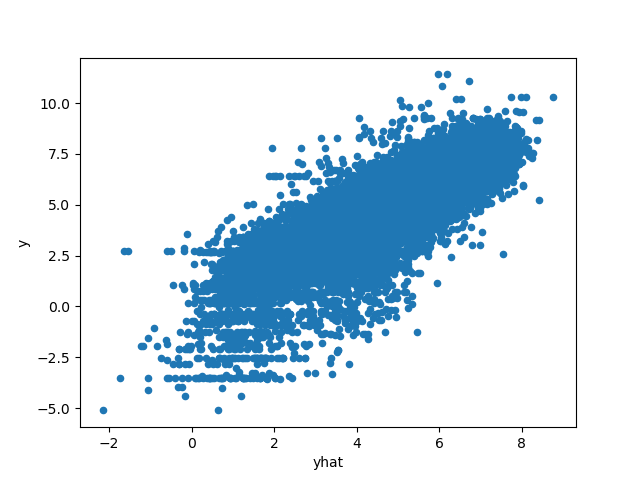

In [33]:
%matplotlib widget
df = pd.DataFrame({'y':log_y,'yhat':result.get_predicted_log_expenditures()})
df.plot.scatter(x='yhat',y='y')
plt.show()

In [13]:
result.get_beta().sort_values()

j
Pineapples                              0.110004
Malt drinks                             0.175755
Kola nut                                0.175997
Ogbono                                  0.188046
Groundnut oil                           0.202537
Palm oil                                0.216506
Chicken                                 0.222732
Brown beans                             0.236294
Pawpaw                                  0.246758
Soft drinks (Coca Cola, spirit, etc)    0.248809
Plantains                               0.278037
Beef                                    0.283670
Gari                                    0.284542
Fish--frozen                            0.287839
Pepper                                  0.323108
Garden eggs/egg plant                   0.325827
Other vegetables (fresh or canned)      0.329848
Eggs                                    0.343187
Tomato puree (canned)                   0.346697
Watermelon                              0.356503
White beans       

In [14]:
result.gamma

k,Female 00-03,Female 04-08,Female 09-13,Female 14-18,Female 19-30,Female 31-50,Female 51+,Female NA,Male 00-03,Male 04-08,Male 09-13,Male 14-18,Male 19-30,Male 31-50,Male 51+,Male NA,log HSize,Constant
j,,,,,,,,,,,,,,,,,,
Bananas,-0.073013,0.070019,0.096545,0.108353,0.150393,0.165893,0.150281,0.024814,0.046503,0.034176,0.083921,0.113344,0.053774,0.108180,0.085294,-0.017933,0.047383,5.215043
Beef,-0.004548,0.005960,-0.018177,0.003144,0.081884,0.020772,0.008627,-0.022642,-0.023783,0.044092,-0.007670,0.034180,0.047685,0.109358,0.146129,-0.042846,0.190226,6.759567
Biscuits,-0.001854,0.055226,-0.021374,0.025799,-0.015120,0.051166,-0.135300,-0.010417,0.108349,-0.043725,-0.052534,-0.020993,0.024836,0.108465,0.053022,-0.017397,0.340834,3.994985
Bread,-0.108352,-0.148544,-0.186654,-0.056737,-0.017390,-0.023116,0.032171,-0.093828,-0.048818,-0.011707,-0.048302,0.003657,-0.196795,-0.145219,-0.046244,-0.115196,0.624720,5.507083
Brown beans,-0.009496,0.036456,0.040938,-0.045043,0.062893,0.083456,0.137873,-0.030332,-0.058265,0.108094,0.029861,-0.029247,0.057962,0.116353,-0.011903,-0.029039,0.361071,5.874225
Chicken,0.029744,0.111941,0.057465,-0.003257,0.095947,0.139365,0.078267,0.017335,0.007504,0.051729,0.048046,0.150360,0.074479,-0.011283,0.185726,0.021229,-0.227989,7.152837
Chocolate drinks,-0.011696,-0.018085,-0.007632,0.177774,0.047536,0.097233,0.092393,-0.003222,0.058936,0.037790,-0.098449,0.027890,0.127923,0.131830,0.098284,-0.057528,0.362924,5.347818
Cocoyam,0.017506,-0.009624,0.022849,-0.000189,0.098178,0.091565,0.054931,0.015511,-0.003198,-0.059145,0.086451,-0.029486,0.044738,0.141889,0.133776,-0.029391,0.117694,5.365803
Condiments,0.089226,0.108974,0.175919,-0.038493,0.134788,0.356103,0.227464,-0.075642,0.052687,-0.021934,0.095180,0.117202,0.237487,0.157345,-0.011707,-0.071871,0.353454,4.107178


In [15]:
result.to_pickle('nigerian_result.pickle')

In [16]:
def get_clean_sheet(sheet=None):

    df = read_sheets(NG_URL,sheet=sheet)
    df.columns = [c.strip() for c in df.columns.tolist()]

    df = df.loc[:,~df.columns.duplicated(keep='first')]

    df = df.drop([col for col in df.columns if col.startswith('Unnamed')], axis=1)

    df = df.loc[~df.index.duplicated(), :]

    return df

In [17]:
NG_expenditures = get_clean_sheet("Food Expenditures (2016Q1)")

In [18]:
NG_expenditures.head()

,t,m,i,j,Expenditure
0,2016Q1,North central,140088,Beef,500.000000
1,2016Q1,North central,140088,Bread,197.368433
2,2016Q1,North central,140088,Eggs,60.000000
3,2016Q1,North central,140088,Fish--fresh,980.354529
4,2016Q1,North central,140088,Fresh Pepper,112.195125


In [19]:
p = read_sheets(NG_URL, sheet = "Food Prices (2016Q1)")

In [20]:
import cfe.regression as rgsn
r = rgsn.read_pickle('nigerian_result.pickle')  # Assumes you've already set this up e.g., in Project 3


In [21]:
pbar = p.groupby('j')['Price'].mean()
pbar = pbar[r.beta.index] # Only use prices for goods we can estimate

In [22]:
HH_characteristics = read_sheets(NG_URL, sheet = "Household Characteristics")

In [23]:
FCT = pd.read_csv("NigerianFCT.csv")

In [24]:
FCT = FCT.rename(columns = {'Unnamed: 0' : 'j'})

In [25]:
RDI = pd.read_csv('NigerianRDI.csv')

In [26]:
import numpy as np

xhat = r.predicted_expenditures()

# Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()

# Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

In [27]:
xref

np.float64(15619.762191007929)

In [28]:
qhat = (xhat.unstack('j')/pbar).dropna(how='all')

# Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

qhat

,,j,Bananas,Beef,Biscuits,Bread,Brown beans,Chicken,Chocolate drinks,Cocoyam,Condiments,Eggs,...,Salt,"Soft drinks (Coca Cola, spirit, etc)",Sugar,Sweet potatoes,Tea,Tomato puree (canned),Tomatoes,Watermelon,White beans,Yam--roots
i,t,m,,,,,,,,,,,,,,,,,,,,,
10001,2016Q1,south east,1.115353,0.985875,0.175078,1.252425,1.356521,1.430572,0.135295,1.441031,0.184704,0.137128,...,0.168322,1.038487,0.115192,1.837988,0.027959,0.223161,1.135049,4.834810,1.296786,10.758984
10002,2016Q1,south east,1.331909,1.208527,0.229007,3.733499,1.350642,1.722139,0.318005,2.068230,0.360398,0.158007,...,0.412763,1.084841,0.221322,3.304496,0.087541,0.235269,1.726713,5.940646,1.672820,15.378039
10003,2016Q1,south east,1.118062,1.026274,0.126578,1.129347,1.075674,1.395224,0.127088,1.503929,0.168574,0.116121,...,0.158253,1.097295,0.122061,2.469352,0.041353,0.209090,1.014862,4.810767,1.358221,11.437190
10004,2016Q1,south east,1.078760,0.970528,0.109292,1.592027,1.096141,1.388063,0.131934,1.461382,0.153226,0.097985,...,0.159837,0.998702,0.111994,2.812724,0.043796,0.187149,1.094369,5.287222,1.244191,11.718531
10005,2016Q1,south east,1.450775,1.055790,0.164304,1.312352,1.416582,1.277544,0.158789,1.711149,0.336489,0.155609,...,0.231416,1.228779,0.181754,2.225617,0.085083,0.163653,1.219287,5.660818,1.597103,13.385565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370036,2016Q1,north central,0.930348,1.000908,0.145251,0.588576,1.509571,1.222790,0.082811,1.486383,0.130756,0.182843,...,0.162007,1.152854,0.206812,1.313890,0.051965,0.272673,0.759420,5.349193,1.775075,14.254794
370037,2016Q1,north central,0.359876,0.486750,0.041617,0.031328,0.849293,0.825129,0.005373,0.539710,0.014311,0.075280,...,0.015986,0.679790,0.027195,0.501567,0.003955,0.111120,0.214441,2.757805,0.785947,6.090452
370038,2016Q1,north central,0.421751,0.594080,0.055121,0.091040,1.012993,0.882402,0.013922,0.629720,0.022794,0.092058,...,0.025699,0.719588,0.043142,0.674491,0.012837,0.125185,0.321005,3.460177,0.917241,7.078883


In [29]:
def my_prices(p0, p=pbar, j=None):
    p = p.copy()
    if j is not None:
        p.loc[j] = p0
    return p

In [30]:
r.demands(xref,pbar)

j
Bananas                                 0.938295
Beef                                    0.952433
Biscuits                                0.323108
Bread                                   0.597134
Brown beans                             1.087958
Chicken                                 1.042662
Chocolate drinks                        0.054494
Cocoyam                                 1.067173
Condiments                              0.090689
Eggs                                    0.505140
Fish--dried                             0.607532
Fish--frozen                            0.978286
Fish--smoked                            0.717188
Fresh Pepper                            0.467611
Garden eggs/egg plant                   0.936737
Gari                                    0.954628
Groundnut oil                           0.881283
Groundnuts                              0.330448
Kola nut                                0.648638
Leaves (Cocoyam, Spinach, etc.)         1.004908
Malt drinks       

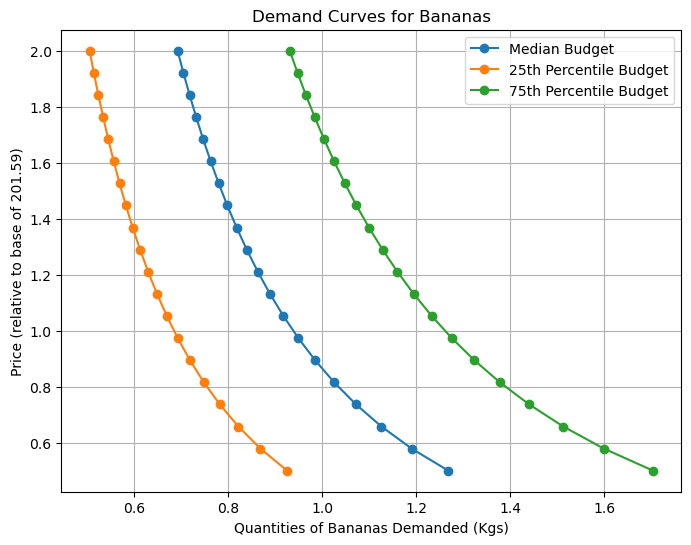

In [31]:
import numpy as np

%matplotlib inline

plt.close('all')          # optional: closes old figures
plt.figure(figsize=(8,6)) # start a new clean figure

use = 'Bananas'   # Good we want demand curve for
scale = np.linspace(0.5, 2, 20)

plt.close('all')
plt.figure(figsize=(8,6))

# Median budget household
median_demands = [
    r.demands(
        xref,
        my_prices(pbar[use] * s, pbar, j=use)
    )[use]
    for s in scale
]

# 25th percentile household
q25_demands = [
    r.demands(
        xbar.quantile(0.25),
        my_prices(pbar[use] * s, pbar, j=use)
    )[use]
    for s in scale
]

# 75th percentile household
q75_demands = [
    r.demands(
        xbar.quantile(0.75),
        my_prices(pbar[use] * s, pbar, j=use)
    )[use]
    for s in scale
]

# Plot all three demand curves
plt.plot(median_demands, scale, marker='o', label='Median Budget')
plt.plot(q25_demands, scale, marker='o', label='25th Percentile Budget')
plt.plot(q75_demands, scale, marker='o', label='75th Percentile Budget')

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded (Kgs)")
plt.title(f"Demand Curves for {use}")
plt.legend()
plt.grid(True)

plt.show()


/srv/conda/lib/python3.11/site-packages/consumerdemands/root_with_precision.py:83: UserWarning: Tolerance is set to 1.00E-12.  Change in value is -2.98E-08.  Iterations are 1001.  Perhaps tolerance is too high?
  warn("Tolerance is set to %.2E.  Change in value is %.2E.  Iterations are %d.  Perhaps tolerance is too high?" % (tol,x[0]-x[-1],i))
/srv/conda/lib/python3.11/site-packages/consumerdemands/root_with_precision.py:83: UserWarning: Tolerance is set to 1.00E-12.  Change in value is -7.45E-09.  Iterations are 1001.  Perhaps tolerance is too high?
  warn("Tolerance is set to %.2E.  Change in value is %.2E.  Iterations are %d.  Perhaps tolerance is too high?" % (tol,x[0]-x[-1],i))
/srv/conda/lib/python3.11/site-packages/consumerdemands/root_with_precision.py:83: UserWarning: Tolerance is set to 1.00E-12.  Change in value is -3.73E-09.  Iterations are 1001.  Perhaps tolerance is too high?
  warn("Tolerance is set to %.2E.  Change in value is %.2E.  Iterations are %d.  Perhaps toleranc

Text(0.5, 1.0, 'Engel Curves')

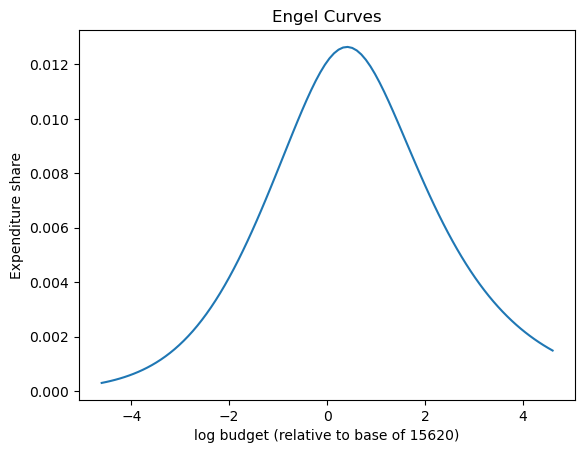

In [32]:
fig,ax = plt.subplots()

scale = np.geomspace(0.01,100,100)
ax.plot(np.log(scale),[(r.expenditures(s*xref,pbar)/(s*xref))['Bananas'] for s in scale])
ax.set_xlabel(f'log budget (relative to base of {xref:.0f})')
ax.set_ylabel(f'Expenditure share')
ax.set_title('Engel Curves')